# Study · Predicting the inclination from the extended sensor package

Station 02 was re-instrumented on 21 February 2025 with a package that records
air temperature, relative humidity, wall temperature, solar radiation, battery
voltage and inclination on the same logger. This study asks what that package
buys as a *prediction* system, in three questions:

1. **Can one sensor channel predict the inclination, and which is best?**
2. **Can a combination beat the best single channel, and how is the best
   combination diagnosed?**
3. **Under the best scenario, how far ahead can NeuralProphet forecast, and
   with what quantified uncertainty?**

## Premises

Three premises are imposed by the study design and are not tested here. They
differ deliberately from those of `../thermal_compensation/`, which examined
exactly these assumptions and rejected two of them; this study accepts them and
asks a different question on top.

| Premise | Consequence |
|---|---|
| The logged `I` channel is an inclination in millidegrees | The 2500 offset the sibling study subtracts is added back. The compensation normalises the series to start at zero, so no model below is affected — only the printed levels. |
| The documented temperature compensation is correct | The compensated series `inc_comp` is the target of every model. Its coefficient is never swept, and the acceptance tests of the sibling study are not repeated. |
| The analysis grid is one hour | Every external proxy the production pipeline aligns against is published hourly, so the study aggregates immediately after parsing and computes every correlation, lag, fit and forecast on that grid. |

One consequence of the second premise must be stated once and kept in view. The
compensation subtracts five millidegrees per degree of air temperature from the
target. Air temperature therefore enters the ranking below as a predictor of a
series from which part of its own signature has already been removed. That does
not invalidate any number here — it changes what the numbers mean, and the
interpretation sections say so where it matters.

## The expected sign

The wall stands in an embankment situation with a **valley side** and a
**mountain side**. The valley side is the more exposed to the sun, so under
daytime heating it expands further and the differential expansion tips the wall
**towards the mountain** — a **negative** change under the instrument's
convention. The site physics therefore predicts a negative association between
the inclination and every heating driver. Step 4b tests that prediction on the
raw channel, before the compensation can manufacture the expected sign out of
an unexpected one.

## Steps

1. **Load** the current era, aggregate to the hourly grid, restore the offset.
2. **Windows** — establish which periods carry which channels, and fix the two
   tiers the study works in.
3. **Description** — the signal, its drivers, and their diurnal structure.
4. **Correlation structure** on levels and on first differences, then the
   **expected sign** tested on the raw channel.
5. **Operator scan** — transport delay against thermal inertia, capped at 12
   hours, full band and diurnal band. *(Question 1, core)*, followed by the
   **wall probe's phase** over signed delays — diagnostic only.
6. **Single-predictor ranking** without autoregression. *(Question 1, answer)*
7. **Collinearity** among the candidates.
8. **Exhaustive subset search**. *(Question 2, answer)*
9. **Diagnostics** — leave-one-out gain and permutation importance.
10. **Diagnostic protocol** — the reusable recipe.
11. **Horizon and uncertainty** under NeuralProphet, two regressor regimes.
    *(Question 3)*
12. **Verdicts.**

## Imports and configuration

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, os.path.abspath('.'))       # ip_lib, local to this study
sys.path.insert(0, os.path.abspath('../../..'))   # heritageshm, at the repo root

import ip_lib as ip
import tc_lib as tc                            # pulled in by ip_lib's path setup

warnings.filterwarnings('ignore')
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 60)

### Parameters

| Parameter | Purpose |
|---|---|
| `ARCHIVE_DIR` | Read-only `.adc` archive. Never written to. |
| `CACHE_DIR` | Local working copy; Google Drive streaming is too slow to read in place. |
| `ANALYSIS_FREQ` | Analysis grid. One hour, matching every external proxy. |
| `CONTEXT` | Seaborn context. `'notebook'` while working, `'paper'` to export manuscript-sized figures from the same code. |
| `ERA` | Bounds of the extended-package era. |
| `TIER1_WINDOW` | The long stretch in which every channel including wall temperature is valid. |
| `TIER1_HOLDOUT` | The detached summer block, used as an out-of-period check. |
| `DELAYS` / `TAUS` | Grid of transport delays and thermal time constants scanned jointly. |
| `DETREND_HOURS` | Width of the rolling mean removed to isolate the diurnal band. |
| `CV_SPLITS` | Rolling-origin folds used by every screening score. |
| `HORIZONS` | Forecast horizons reported, in hours. |
| `RUN_NEURALPROPHET` | Whether to run the horizon study, which dominates the runtime. |

In [2]:
ARCHIVE_DIR = os.path.expanduser(
    '~/Library/CloudStorage/GoogleDrive-eugeniomoreira@iaud.ufc.br/'
    'My Drive/_UNIPG/__Mura-realtime'
)
CACHE_DIR  = '.cache'
OUTPUT_DIR = 'outputs'
STATION    = 'st02'

ANALYSIS_FREQ = '1h'
CONTEXT       = 'notebook'      # 'paper' re-exports every figure at column size
SAMPLING_HOURS = 1.0

# The extended package, from the changeover to the end of the archive.
ERA = ('2025-02-21', '2026-08-10')

# Wall temperature is valid in two blocks only (docs/data-quality-report).
TIER1_WINDOW  = ('2025-02-21', '2025-07-13')   # 143 days
TIER1_HOLDOUT = ('2026-06-18', '2026-08-10')   #  54 days

TARGET          = 'inc_comp'
DRIVERS         = ip.PHYSICAL_DRIVERS            # tair, twall, sr, rh
CONTROL         = ip.CONTROL_DRIVER              # batt, negative control
TIER2_DRIVERS   = ['tair', 'sr', 'rh']           # everything that survives without twall

# Transport delay is capped at 12 hours on physical grounds. The mechanism is
# the heating of a masonry embankment by direct insolation on one face; a front
# reaching the depth that moves the instrument cannot plausibly take longer than
# half a day, and the site imposes no process that would. The cap is not merely
# a convenience: on a near-periodic diurnal signal the scan cannot distinguish a
# delay of d hours from a lead of 24 - d, so admitting delays beyond half a
# cycle invites an optimum that is really an aliased lead. Twelve hours is the
# half-cycle, and stopping there keeps every reported optimum interpretable.
MAX_DELAY_H   = 12
DELAYS        = list(range(0, MAX_DELAY_H + 1))
TAUS          = [0, 1, 2, 3, 4, 6, 8, 12, 18, 24, 36, 48, 72, 96, 120, 168]
DETREND_HOURS = 168                               # one week, isolates the diurnal band

# Signed delays, for the probe-phase diagnostic of Step 5b only. These admit a
# negative optimum, meaning the driver lags the response. That is excluded from
# every predictive model below by the causal guard in `operators_from_summary`,
# because using it would require the driver's future values at forecast time.
SIGNED_DELAYS = list(range(-MAX_DELAY_H, MAX_DELAY_H + 1))
PHASE_PAIRS   = [
    (TARGET, 'twall'),   # compensated inclination against the wall probe
    ('inc',  'twall'),   # raw inclination against the wall probe
    ('twall', 'tair'),   # the probe's own damping, independent of compensation
    ('twall', 'sr'),     # and against the radiation that drives it
    (TARGET, 'tair'),    # control: an external forcing must not lag the response
    (TARGET, 'sr'),      # control
]

CV_SPLITS      = 5
MIN_TRAIN_FRAC = 0.5
RIDGE_ALPHA    = 1.0

MAX_HORIZON       = 168                           # one week
HORIZONS          = [1, 3, 6, 12, 24, 48, 72, 168]
QUANTILES         = (0.05, 0.95)
NP_LAGS           = 24
NP_EPOCHS         = 30
NP_TRAIN_FRAC     = 0.70
RUN_NEURALPROPHET = True

os.makedirs(OUTPUT_DIR, exist_ok=True)
ip.set_context(CONTEXT)

'notebook'

## Step 1 · Load the extended-package era

The loader applies the contract in `docs/raw-data-format.md`: per-field decimal
normalisation, dates taken from the record rather than the filename, field-wise
merging of duplicate timestamps, and every sentinel mapped to `NaN` — zeros in
the battery, temperature, humidity and inclination channels, `-55` in the wall
probe, and the unsigned wrap-around above 1400 W/m² in the pyranometer.
Night-time zeros in solar radiation are kept, because they are measurements.

It then aggregates to the hourly grid, accepting an hour only when at least two
of its three raw samples survived cleaning.

In [3]:
df = ip.load_current(ARCHIVE_DIR, CACHE_DIR, ERA[0], ERA[1],
                     freq=ANALYSIS_FREQ)
df, flagged = tc.screen_spikes(df, col='inc', window=3, k=8.0)
df = ip.add_target(df)
print(f'grid: {len(df)} hourly slots, {df.index.min()} to {df.index.max()}')
df.head()

  cache: 416 files in range, 0 newly copied, 416 already present


  parsed  : 29647 records from 416 files
  duplicates: 17 records share a timestamp, 10 field-level conflicts merged
  sentinels : 0 zeros, 15566 Twall = -55, 3100 SR > 1400 W/m2, 0 inclinometer out of range
  grid      : 38593 slots from 2025-02-21 00:00:00 to 2026-08-11 00:00:00
  resampled : 38593 native slots to 12865 at 1h; 9919 intervals carry the inclinometer, 6 rejected for holding fewer than 2 raw samples
  premise   : inclinometer offset of 2500 restored; the logged channel is read as millidegrees
  spike screen on "inc": robust sigma of signal 14.70 mdeg, threshold 117.6 mdeg, 59 of 9860 samples removed (0.60 %)
grid: 12865 hourly slots, 2025-02-21 00:00:00 to 2026-08-11 00:00:00


,batt,tair,rh,sr,twall,inc,inc_comp
datetime,,,,,,,
2025-02-21 00:00:00,4.957333,2.936667,99.991667,0.0,2.683333,2148.083333,0.000000
2025-02-21 01:00:00,4.961667,2.911667,99.991667,0.0,2.433333,2147.500000,-0.458333
2025-02-21 02:00:00,4.963667,3.041667,99.993333,0.0,2.143333,2147.125000,-1.483333
2025-02-21 03:00:00,4.960667,3.030000,99.991667,0.0,1.933333,2147.125000,-1.425000
2025-02-21 04:00:00,4.964333,3.015000,99.990000,0.0,1.830000,2146.958333,-1.516667


The target is the compensated inclination. Its level is an artefact of where
the window begins — the compensation normalises the series to start at zero —
so only its changes carry information.

In [4]:
summary_stats = df[['inc', TARGET, 'tair', 'twall', 'sr', 'rh', 'batt']] \
    .describe().T.round(3)
display(summary_stats)
summary_stats.to_csv(f'{OUTPUT_DIR}/S3_01_{STATION}_channel_summary.csv')

,count,mean,std,min,25%,50%,75%,max
inc,9860.0,2184.323,14.530,2090.125,2173.625,2183.833,2193.417,2238.417
inc_comp,9860.0,-28.587,40.734,-181.175,-61.427,-23.483,7.702,50.125
tair,9919.0,16.009,8.924,-5.172,8.272,14.747,22.889,38.320
twall,4706.0,23.154,11.617,1.247,13.370,22.683,29.790,55.557
sr,8884.0,244.410,335.320,0.000,2.292,128.000,282.427,1358.000
rh,9919.0,75.621,20.539,25.252,57.963,80.062,95.322,99.995
batt,9919.0,4.161,0.396,3.271,3.873,4.192,4.472,4.964


## Step 2 · Which periods carry which channels

Wall temperature is the binding constraint of this era: the probe reads its
open-circuit sentinel on 219 of the 416 days present. Every other channel is
available whenever the logger is. That asymmetry forces the study into two
tiers rather than one, and the choice between them is not obvious in advance —
which is the substance of Question 2.

In [5]:
coverage = tc.coverage_table(df)
display(coverage)
coverage.to_csv(f'{OUTPUT_DIR}/S3_02_{STATION}_coverage.csv')

,present,missing,available_%,min,max,mean,std
channel,,,,,,,
batt,9919,2946,77.101,3.271,4.964,4.161,0.396
tair,9919,2946,77.101,-5.172,38.320,16.009,8.924
rh,9919,2946,77.101,25.252,99.995,75.621,20.539
sr,8884,3981,69.056,0.000,1358.000,244.410,335.320
twall,4706,8159,36.580,1.247,55.557,23.154,11.617
inc,9860,3005,76.642,2090.125,2238.417,2184.323,14.530
inc_comp,9860,3005,76.642,-181.175,50.125,-28.587,40.734


In [6]:
blocks_all = ip.contiguous_blocks(df, [TARGET] + DRIVERS, min_days=20)
blocks_notwall = ip.contiguous_blocks(df, [TARGET] + TIER2_DRIVERS,
                                      min_days=20)
print('Runs with every channel valid, wall temperature included:')
display(blocks_all)
print('Runs with wall temperature dropped:')
display(blocks_notwall)
blocks_all.to_csv(f'{OUTPUT_DIR}/S3_03_{STATION}_blocks_all_channels.csv',
                  index=False)
blocks_notwall.to_csv(f'{OUTPUT_DIR}/S3_04_{STATION}_blocks_no_twall.csv',
                      index=False)

Runs with every channel valid, wall temperature included:


,start,end,days,coverage_%
0,2025-02-21 00:00:00,2025-05-05 03:00:00,73.1,99.5
1,2025-05-05 11:00:00,2025-07-14 02:00:00,69.6,99.9
2,2026-06-18 13:00:00,2026-08-10 20:00:00,53.3,95.7


Runs with wall temperature dropped:


,start,end,days,coverage_%
0,2025-05-05 11:00:00,2025-09-25 16:00:00,143.2,99.9
1,2025-11-25 11:00:00,2026-03-06 11:00:00,101.0,99.7
2,2025-02-21 00:00:00,2025-05-05 03:00:00,73.1,99.5
3,2026-06-18 13:00:00,2026-08-10 20:00:00,53.3,95.7


### The two tiers

**Tier 1** is the long wall-temperature-valid window, with the detached summer
block held back as an out-of-period check. It is the only setting in which the
question *is wall temperature worth having* can be asked at all.

**Tier 2** drops wall temperature and takes the longest contiguous run that
remains. It is what a deployed system actually has for most of the record, and
it is the only window long enough to support a one-week forecast horizon.

In [7]:
tier1 = df.loc[TIER1_WINDOW[0]:TIER1_WINDOW[1]].copy()
tier1_holdout = df.loc[TIER1_HOLDOUT[0]:TIER1_HOLDOUT[1]].copy()

if len(blocks_notwall):
    t2_start = blocks_notwall.iloc[0]['start']
    t2_end = blocks_notwall.iloc[0]['end']
else:
    t2_start, t2_end = df.index.min(), df.index.max()
tier2 = df.loc[t2_start:t2_end].copy()

for name, w, cols in [('Tier 1 window ', tier1, [TARGET] + DRIVERS),
                      ('Tier 1 holdout', tier1_holdout, [TARGET] + DRIVERS),
                      ('Tier 2 block  ', tier2, [TARGET] + TIER2_DRIVERS)]:
    complete = w[cols].dropna()
    print(f'{name}: {w.index.min().date()} to {w.index.max().date()} | '
          f'{len(w)} slots | {len(complete)} complete rows '
          f'({100 * len(complete) / max(len(w), 1):.1f} %) | '
          f'{(w.index.max() - w.index.min()).days} days')

Tier 1 window : 2025-02-21 to 2025-07-13 | 3432 slots | 3415 complete rows (99.5 %) | 142 days
Tier 1 holdout: 2026-06-18 to 2026-08-10 | 1296 slots | 1225 complete rows (94.5 %) | 53 days
Tier 2 block  : 2025-05-05 to 2025-09-25 | 3438 slots | 3435 complete rows (99.9 %) | 143 days


## Step 3 · What the signal and its drivers look like

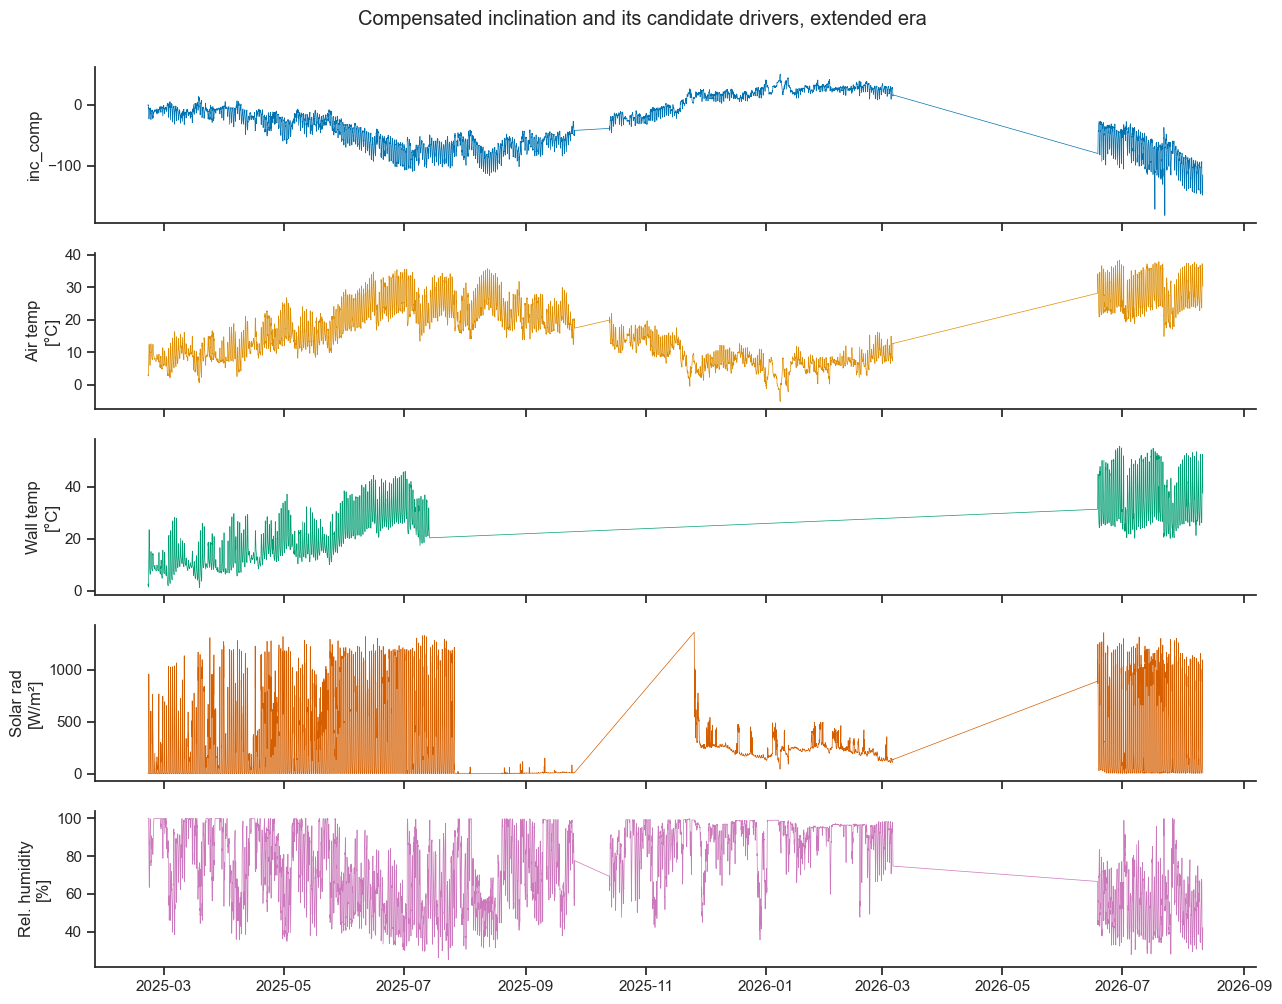

In [8]:
tc.plot_overview(
    df, cols=('inc_comp', 'tair', 'twall', 'sr', 'rh'),
    title='Compensated inclination and its candidate drivers, extended era',
    save_path=OUTPUT_DIR, filename=f'S3_F01_{STATION}_overview')
plt.show()

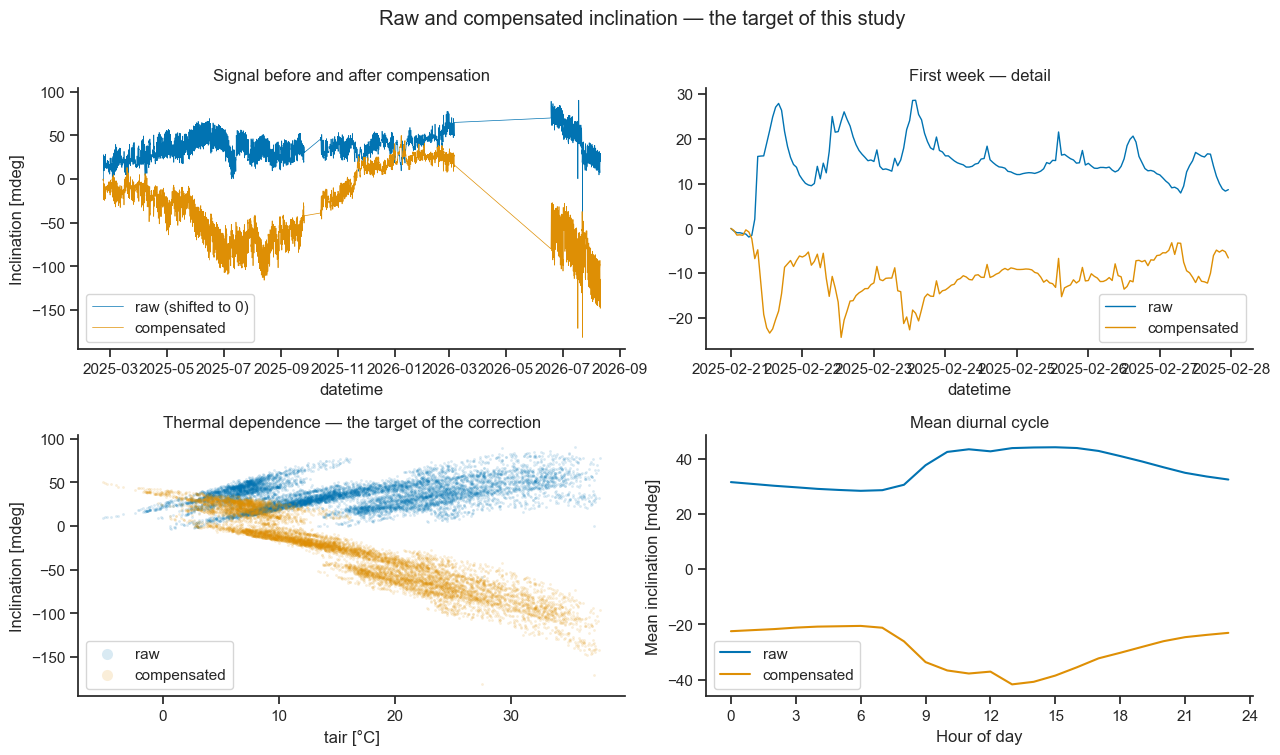

In [9]:
tc.plot_compensation_effect(
    df, df[TARGET], temp_col='tair',
    title='Raw and compensated inclination — the target of this study',
    save_path=OUTPUT_DIR, filename=f'S3_F02_{STATION}_target')
plt.show()

### Diurnal structure

The mechanism under test is differential thermal expansion driven by unequal
solar exposure of the two faces. If that mechanism operates, the inclination
must carry a daily cycle whose phase sits behind the radiation that drives it.

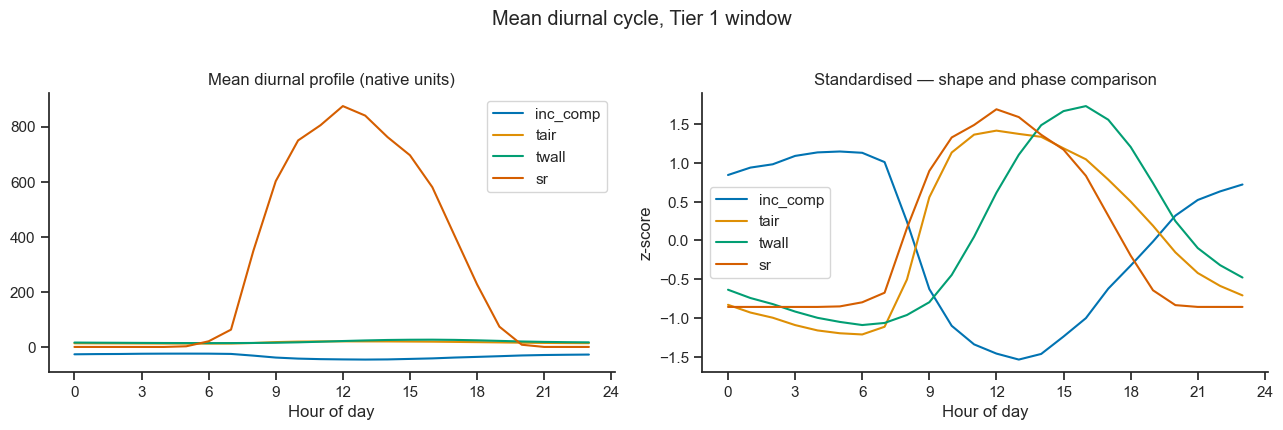

In [10]:
tc.plot_diurnal(
    tier1, cols=('inc_comp', 'tair', 'twall', 'sr'),
    title='Mean diurnal cycle, Tier 1 window',
    save_path=OUTPUT_DIR, filename=f'S3_F03_{STATION}_diurnal')
plt.show()

## Step 4 · Correlation structure

Levels correlations between two trending series are inflated by the shared
trend. The differenced matrix is the honest one for a signal with drift, and
both are reported so that the gap between them is visible.

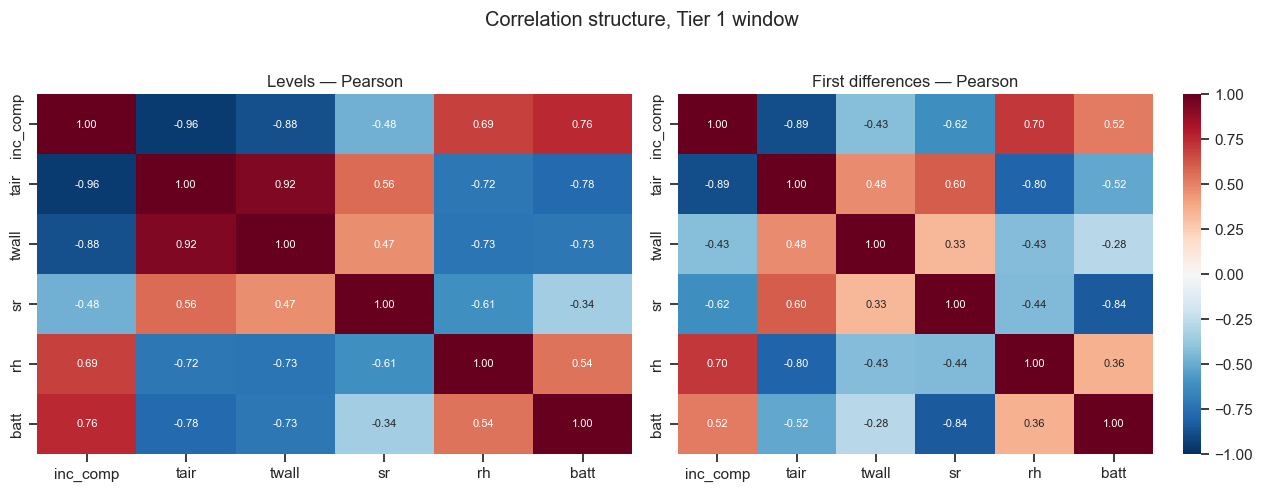

,inc_comp,tair,twall,sr,rh,batt
inc_comp,1.000,-0.956,-0.878,-0.478,0.687,0.757
tair,-0.956,1.000,0.924,0.564,-0.720,-0.777
twall,-0.878,0.924,1.000,0.468,-0.730,-0.725
sr,-0.478,0.564,0.468,1.000,-0.610,-0.344
rh,0.687,-0.720,-0.730,-0.610,1.000,0.543
batt,0.757,-0.777,-0.725,-0.344,0.543,1.000


In [11]:
corr_cols = [TARGET, 'tair', 'twall', 'sr', 'rh', CONTROL]
tc.plot_correlation_heatmaps(
    tier1, corr_cols,
    title='Correlation structure, Tier 1 window',
    save_path=OUTPUT_DIR, filename=f'S3_F04_{STATION}_correlations')
plt.show()

corr_levels = tc.correlation_matrix(tier1, corr_cols, differenced=False)
corr_diff = tc.correlation_matrix(tier1, corr_cols, differenced=True)
corr_levels.round(3).to_csv(f'{OUTPUT_DIR}/S3_05_{STATION}_corr_levels.csv')
corr_diff.round(3).to_csv(f'{OUTPUT_DIR}/S3_06_{STATION}_corr_diff.csv')
display(corr_levels.round(3))

## Step 4b · The expected sign, and whether the data show it

The wall stands in an embankment situation with two distinct faces. The
**valley side** receives markedly more direct insolation than the **mountain
side**, so under daytime heating it expands further, and the differential
expansion tips the wall **towards the mountain**. Under the instrument's
convention that is a **negative** change in inclination.

The site physics therefore predicts a **negative** association between the
inclination and any heating driver — air temperature, wall temperature, solar
radiation. This is a prediction about the structure, so it has to be tested on
the signal *before* the compensation touches it.

The distinction matters because the compensation can manufacture the expected
sign without the structure supplying it. It subtracts 5 mdeg per degree of air
temperature; if the instrument's true thermal slope is smaller than that, the
residual carries the opposite sign to the original by arithmetic alone. A
negative sign already present in the raw channel is structural; a negative sign
that appears only after compensation is not.

In [12]:
signs = ip.sign_table(tier1, ['inc', TARGET], ['tair', 'twall', 'sr'],
                      detrend_hours=DETREND_HOURS, dt_hours=SAMPLING_HOURS)
display(signs)
signs.to_csv(f'{OUTPUT_DIR}/S3_23_{STATION}_sign_convention.csv')

r_levels  slope_levels  r_band  slope_band
target   driver                                            
inc      tair      0.8446        1.6279  0.9655      2.2909
         twall     0.7908        1.2476  0.7669      1.3185
         sr        0.5880        0.0214  0.7583      0.0173
inc_comp tair     -0.9562       -3.3721 -0.9750     -2.7087
         twall    -0.8781       -2.5348 -0.7006     -1.4105
         sr       -0.4784       -0.0319 -0.8025     -0.0215

In [13]:
raw_slope = signs.loc[('inc', 'tair'), 'slope_levels']
print(f'Raw inclination against air temperature: '
      f'r = {signs.loc[("inc", "tair"), "r_levels"]:+.3f}, '
      f'slope = {raw_slope:+.3f} mdeg/degC')
print(f'Compensated                            : '
      f'r = {signs.loc[(TARGET, "tair"), "r_levels"]:+.3f}, '
      f'implied residual slope = {raw_slope - 5.0:+.3f} mdeg/degC')

Raw inclination against air temperature: r = +0.845, slope = +1.628 mdeg/degC
Compensated                            : r = -0.956, implied residual slope = -3.372 mdeg/degC


## Step 5 · Operator scan — delay against inertia

**Question 1, core.** A structure with thermal mass cannot respond to a change
in forcing instantaneously, so before any driver is ranked it must be given the
chance to act through the operator that suits it. Two operators are scanned
jointly, because they are physically distinct and a scan of either alone can
attribute to one what belongs to the other:

* a **transport delay** shifts the driver without changing its shape, which is
  what a thermal front travelling from the exposed face to the depth that moves
  the instrument would do;
* a **thermal inertia** low-passes the driver with a time constant `τ`, which
  is what a body integrating the forcing would do.

The grid is 13 delays by 16 time constants for each driver, scored by explained
variance.

**The delay stops at 12 hours, on physical grounds.** The mechanism is direct
insolation heating one face of a masonry embankment; a thermal front reaching
the depth that moves the instrument cannot plausibly take longer than half a
day, and nothing at the site imposes a slower transport process. The cap also
removes a trap. On a near-periodic diurnal signal a delay of `d` hours is
indistinguishable from a lead of `24 − d`, so a grid extending past half a
cycle can return an optimum that is really an aliased lead — which a causal
filter cannot represent and a forecasting system cannot use. Twelve hours is
the half-cycle, and stopping there keeps every reported optimum interpretable.

The scan is run twice: once on the series as they are, and once on the diurnal
band alone, with a one-week centred rolling mean removed. The two are different
questions. The sibling study found the inclination *leading* air temperature by
roughly two months at the annual scale while following it within the hour at
the daily scale, and no causal operator can produce a lead. Mixing the bands
therefore returns an operator that suits neither.

In [14]:
ops_full, scans_full = ip.operator_table(
    tier1, TARGET, DRIVERS + [CONTROL], DELAYS, TAUS,
    dt_hours=SAMPLING_HOURS, detrend_hours=None)
display(ops_full)
ops_full.to_csv(f'{OUTPUT_DIR}/S3_07_{STATION}_operators_fullband.csv')

,delay_h,tau_h,r,r2,r2_instantaneous,gain_from_operator
driver,,,,,,
tair,0.0,0.0,-0.9562,0.9144,0.9144,0.0000
twall,12.0,120.0,-0.8879,0.7884,0.7711,0.0173
sr,0.0,168.0,-0.8134,0.6616,0.2288,0.4327
rh,0.0,168.0,0.8531,0.7278,0.4716,0.2562
batt,0.0,0.0,0.7573,0.5736,0.5736,0.0000


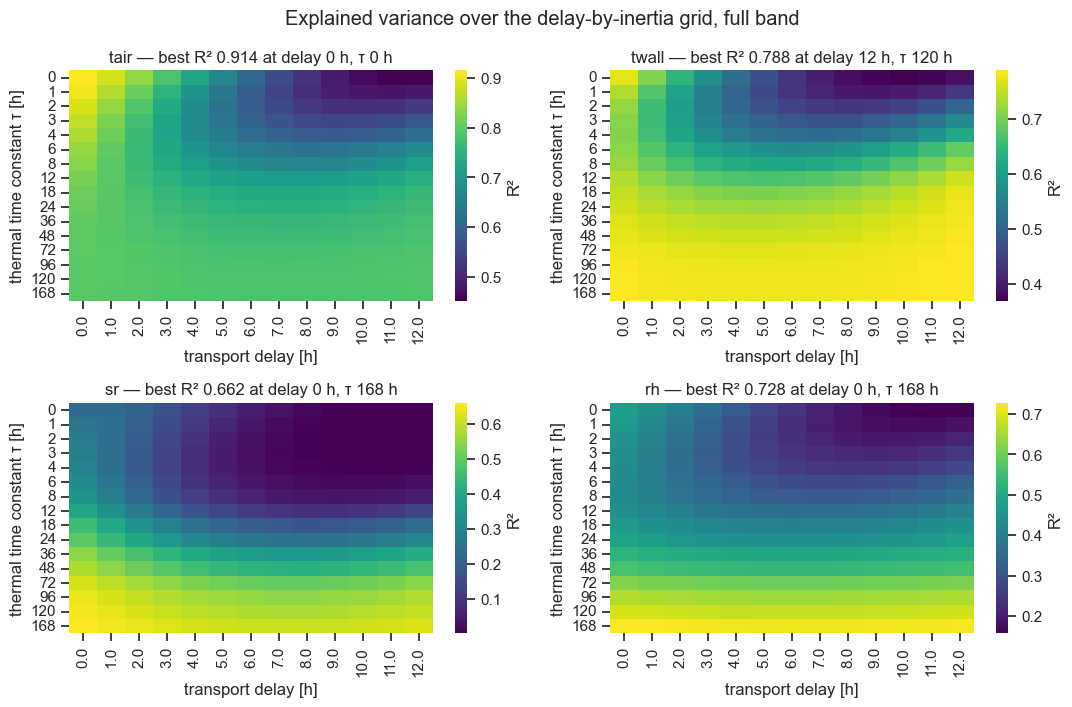

In [15]:
ip.plot_operator_heatmaps(
    {k: scans_full[k] for k in DRIVERS},
    title='Explained variance over the delay-by-inertia grid, full band',
    save_path=OUTPUT_DIR, filename=f'S3_F05_{STATION}_operators_fullband')
plt.show()

In [16]:
ops_band, scans_band = ip.operator_table(
    tier1, TARGET, DRIVERS + [CONTROL], DELAYS, TAUS,
    dt_hours=SAMPLING_HOURS, detrend_hours=DETREND_HOURS)
display(ops_band)
ops_band.to_csv(f'{OUTPUT_DIR}/S3_08_{STATION}_operators_diurnal.csv')

,delay_h,tau_h,r,r2,r2_instantaneous,gain_from_operator
driver,,,,,,
tair,0.0,0.0,-0.9750,0.9507,0.9507,0.0000
twall,0.0,0.0,-0.7006,0.4909,0.4909,0.0000
sr,0.0,1.0,-0.8365,0.6998,0.6440,0.0557
rh,0.0,0.0,0.6951,0.4831,0.4831,0.0000
batt,0.0,1.0,0.8298,0.6885,0.6300,0.0585


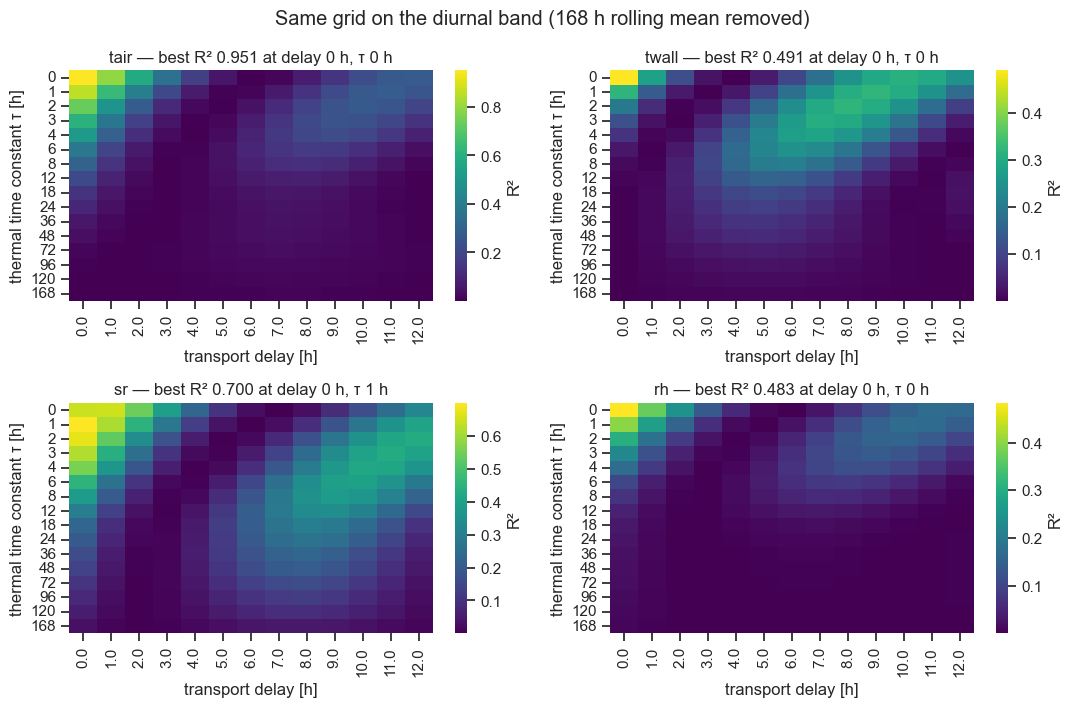

In [17]:
ip.plot_operator_heatmaps(
    {k: scans_band[k] for k in DRIVERS},
    title=f'Same grid on the diurnal band ({DETREND_HOURS} h rolling mean '
          f'removed)',
    save_path=OUTPUT_DIR, filename=f'S3_F06_{STATION}_operators_diurnal')
plt.show()

The operators fitted on the diurnal band are the ones carried forward. They
describe the response a causal filter can actually represent, and they are not
contaminated by the seasonal component whose phase relationship runs the wrong
way for any such filter.

In [18]:
OPERATORS = ip.operators_from_summary(ops_band, dt_hours=SAMPLING_HOURS,
                                      causal_only=True, verbose=True)
for drv, op in OPERATORS.items():
    print(f'{drv:>6}: delay {op["delay"]:>3} h, τ {op["tau"]:>5.0f} h')

  tair: delay   0 h, τ     0 h
 twall: delay   0 h, τ     0 h
    sr: delay   0 h, τ     1 h
    rh: delay   0 h, τ     0 h
  batt: delay   0 h, τ     1 h


## Step 5b · The wall probe's phase — a diagnostic, not a model input

**Nothing in this step feeds any model.** The operators used from here on are
the causal ones fixed above.

The scan in Step 5 constrains the delay to be non-negative, which is correct
for `tair` and `sr`: those are **external forcings**, and a forcing must
precede the response it causes. Applying the same constraint to `twall` is a
different matter, because wall temperature is not a forcing — it is an
**internal state variable**, a temperature measured at some depth inside the
masonry, and there is no physical reason it must precede the deformation.

Which way it runs depends on where the probe sits. The deformation is governed
by the temperature field near the sun-exposed valley face:

| Probe position | What it reads | Expected phase |
|---|---|---|
| **Shallow** | a fast, weakly damped signal close to the surface forcing | the inclination **lags** the probe |
| **Deep** | a strongly damped and delayed signal | the inclination **leads** the probe |

The probe's actual depth is not recorded anywhere in the archive. So this step
measures the **phase**, in hours, and leaves the depth open. When the depth is
established, the sign and magnitude here become the check to run against it,
rather than a reason to redo the analysis.

Two of the pairs below are **controls**. An external forcing that appeared to
lag the response would indicate a fault in the method rather than a physical
finding, so `tair` and `sr` must come out at a non-negative phase.

In [19]:
phase = ip.cross_phase(tier1, PHASE_PAIRS, SIGNED_DELAYS,
                       detrend_hours=DETREND_HOURS, dt_hours=SAMPLING_HOURS)
display(phase)
phase.to_csv(f'{OUTPUT_DIR}/S3_25_{STATION}_probe_phase.csv')

phase_h  r_at_phase  r_at_zero  r2_gain
a        b                                             
inc_comp twall     -2.0     -0.8750    -0.7006   0.2748
inc      twall     -2.0      0.8660     0.7669   0.1619
twall    tair       2.0      0.8973     0.7532   0.2377
         sr         3.0      0.8906     0.5324   0.5098
inc_comp tair       0.0     -0.9750    -0.9750   0.0000
         sr         1.0     -0.8047    -0.8025   0.0036

In [20]:
controls_ok = all(phase.loc[(TARGET, c), 'phase_h'] >= 0
                  for c in ('tair', 'sr'))
print(f'control check — external forcings at non-negative phase: {controls_ok}')
if not controls_ok:
    print('  WARNING: an external forcing appears to lag the response. '
          'Treat every phase below as a method artefact, not a measurement.')

control check — external forcings at non-negative phase: True


### The same scan, over signed delays

Re-running the full operator grid over signed delays shows what the causal
constraint costs for each driver. The controls should peak at or after zero;
only the wall probe has any licence to peak before it.

In [21]:
ops_signed, scans_signed = ip.operator_table(
    tier1, TARGET, DRIVERS, SIGNED_DELAYS, TAUS,
    dt_hours=SAMPLING_HOURS, detrend_hours=DETREND_HOURS)
ops_signed['causal_r2'] = ops_band.loc[ops_signed.index, 'r2']
ops_signed['r2_lost_to_causality'] = (
    ops_signed['r2'] - ops_signed['causal_r2']).round(4)
display(ops_signed)
ops_signed.to_csv(f'{OUTPUT_DIR}/S3_24_{STATION}_operators_signed.csv')

,delay_h,tau_h,r,r2,r2_instantaneous,gain_from_operator,causal_r2,r2_lost_to_causality
driver,,,,,,,,
tair,0.0,0.0,-0.9750,0.9507,0.9507,0.0000,0.9507,0.0000
twall,-4.0,2.0,-0.8925,0.7966,0.4909,0.3057,0.4909,0.3057
sr,0.0,1.0,-0.8365,0.6998,0.6440,0.0557,0.6998,0.0000
rh,0.0,0.0,0.6951,0.4831,0.4831,0.0000,0.4831,0.0000


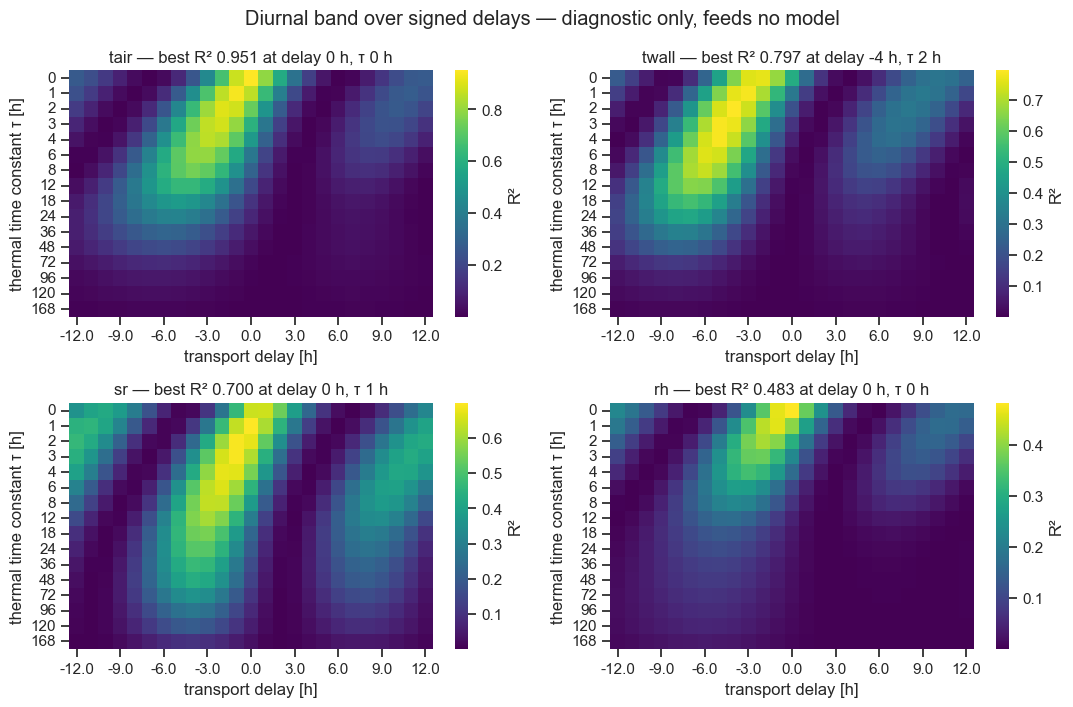

In [22]:
ip.plot_operator_heatmaps(
    {k: scans_signed[k] for k in DRIVERS},
    title='Diurnal band over signed delays — diagnostic only, feeds no model',
    save_path=OUTPUT_DIR, filename=f'S3_F15_{STATION}_operators_signed')
plt.show()

## Step 6 · Ranking the single predictors

**Question 1, answer.** Each driver is scored on its own, at its fitted
operator, by pooled error over five rolling-origin folds — every test block
strictly after the training block it was fitted on.

Autoregression is deliberately excluded. One hour ahead the inclination's own
recent history explains almost all of its variance, and every driver added on
top of it looks equally negligible; a ranking computed that way measures how
little room the autoregressive term leaves, not what the channel knows.
Autoregression returns in Step 11, where it belongs.

Battery voltage is carried through the ranking as a **negative control**. It
rises with insolation and temperature, so it correlates with the real drivers,
but no mechanism connects it to the structure. If it ranks among them, the
procedure is measuring shared diurnal shape rather than predictive content.

In [23]:
rank_t1 = ip.rank_single_predictors(
    tier1, TARGET, DRIVERS + [CONTROL], OPERATORS, dt_hours=SAMPLING_HOURS,
    n_splits=CV_SPLITS, min_train_frac=MIN_TRAIN_FRAC, alpha=RIDGE_ALPHA,
    full_record=df)
display(rank_t1)
rank_t1.to_csv(f'{OUTPUT_DIR}/S3_09_{STATION}_rank_tier1.csv')

,delay_h,tau_h,MAE_mdeg,RMSE_mdeg,R2,MAE_sd,availability_%,n_test,MAE_vs_best_%
driver,,,,,,,,,
tair,0.0,0.0,8.7357,12.1278,0.7595,7.5601,77.1,1710,0.00
twall,0.0,0.0,13.6070,18.1891,0.4591,8.1325,36.6,1710,55.76
batt,0.0,1.0,20.7132,25.2856,-0.0454,9.7917,77.1,1710,137.11
rh,0.0,0.0,24.1007,28.0099,-0.2828,10.7830,77.1,1710,175.89
sr,0.0,1.0,28.4031,33.0839,-0.7876,15.1541,69.1,1708,225.14


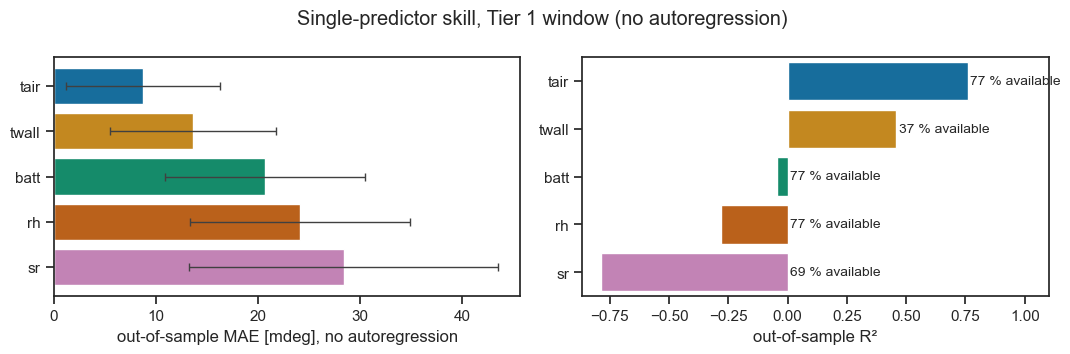

In [24]:
ip.plot_single_ranking(
    rank_t1, title='Single-predictor skill, Tier 1 window (no autoregression)',
    save_path=OUTPUT_DIR, filename=f'S3_F07_{STATION}_rank_tier1')
plt.show()

### The same ranking on the long block

Tier 2 covers a longer and more varied stretch at the cost of wall temperature.
If a channel's rank survives the change of window it is a property of the
structure; if it does not, it was a property of the season.

In [25]:
ops_band_t2, _ = ip.operator_table(
    tier2, TARGET, TIER2_DRIVERS + [CONTROL], DELAYS, TAUS,
    dt_hours=SAMPLING_HOURS, detrend_hours=DETREND_HOURS)
OPERATORS_T2 = ip.operators_from_summary(ops_band_t2, dt_hours=SAMPLING_HOURS)
display(ops_band_t2)
ops_band_t2.to_csv(f'{OUTPUT_DIR}/S3_10_{STATION}_operators_tier2.csv')

,delay_h,tau_h,r,r2,r2_instantaneous,gain_from_operator
driver,,,,,,
tair,0.0,0.0,-0.9787,0.9578,0.9578,0.0000
sr,0.0,1.0,-0.6822,0.4655,0.4241,0.0414
rh,0.0,0.0,0.7896,0.6235,0.6235,0.0000
batt,0.0,1.0,0.7117,0.5065,0.4525,0.0540


In [26]:
rank_t2 = ip.rank_single_predictors(
    tier2, TARGET, TIER2_DRIVERS + [CONTROL], OPERATORS_T2,
    dt_hours=SAMPLING_HOURS, n_splits=CV_SPLITS,
    min_train_frac=MIN_TRAIN_FRAC, alpha=RIDGE_ALPHA, full_record=df)
display(rank_t2)
rank_t2.to_csv(f'{OUTPUT_DIR}/S3_11_{STATION}_rank_tier2.csv')

,delay_h,tau_h,MAE_mdeg,RMSE_mdeg,R2,MAE_sd,availability_%,n_test,MAE_vs_best_%
driver,,,,,,,,,
tair,0.0,0.0,8.2464,9.4518,0.6555,3.0189,77.1,1718,0.00
rh,0.0,0.0,14.6657,17.2539,-0.1478,4.6400,77.1,1718,77.84
sr,0.0,1.0,18.5918,23.3949,-1.1103,8.1799,69.1,1718,125.45
batt,0.0,1.0,30.9000,33.9396,-3.4414,5.1431,77.1,1718,274.71


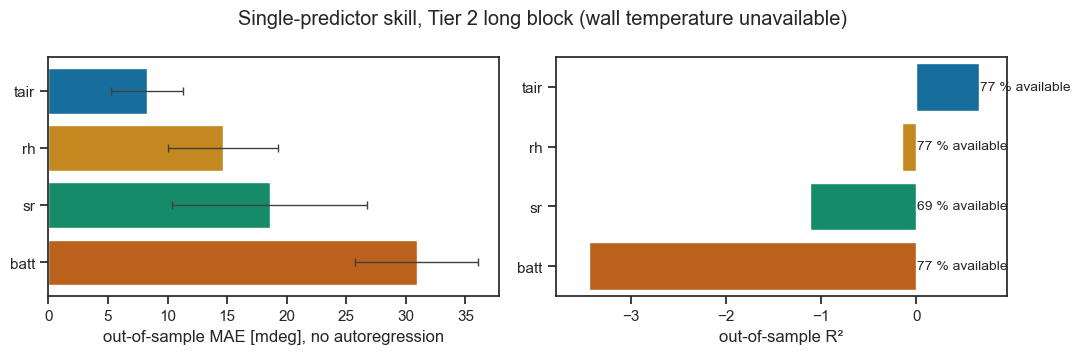

In [27]:
ip.plot_single_ranking(
    rank_t2, title='Single-predictor skill, Tier 2 long block '
                   '(wall temperature unavailable)',
    save_path=OUTPUT_DIR, filename=f'S3_F08_{STATION}_rank_tier2')
plt.show()

## Step 7 · How far the candidates duplicate one another

These channels are physically coupled — radiation heats the air, and the air
and the radiation together heat the wall — so a regression containing several
of them splits one physical effect across correlated coefficients in a way that
is not stable between folds. The variance inflation factor quantifies that
before any coefficient is read for interpretation, and it is the reason the
combination search below is scored by out-of-sample error rather than by
coefficients or by in-sample fit.

In [28]:
vif = ip.vif_table(tier1, DRIVERS)
display(vif)
vif.to_csv(f'{OUTPUT_DIR}/S3_12_{STATION}_vif.csv')

,VIF,max_|r|_with_others,closest
column,,,
tair,8.06,0.924,twall
twall,7.90,0.924,tair
sr,1.82,0.610,rh
rh,2.69,0.732,twall


## Step 8 · Every combination

**Question 2, answer.** With four candidates the search is exhaustive at
fifteen fits, which removes the need for a stepwise procedure and the selection
bias that comes with one. Each subset is scored three ways:

* **pooled rolling-origin MAE** — what it predicts on data it has not seen;
* **BIC** of the corresponding least-squares fit — whether it wins by
  explaining or by spending parameters;
* **availability-weighted utility** — accuracy relative to the best subset,
  multiplied by the fraction of the whole era on which the subset exists. A
  channel that is absent for half the record delivers nothing during that half,
  and an error metric computed only where it is present cannot see that.

In [29]:
subsets_t1 = ip.subset_search(
    tier1, TARGET, DRIVERS, OPERATORS, dt_hours=SAMPLING_HOURS,
    n_splits=CV_SPLITS, min_train_frac=MIN_TRAIN_FRAC, alpha=RIDGE_ALPHA,
    full_record=df)
display(subsets_t1)
subsets_t1.to_csv(f'{OUTPUT_DIR}/S3_13_{STATION}_subsets_tier1.csv')

,k,MAE_mdeg,RMSE_mdeg,R2,MAE_sd,BIC,availability_%,n_test,MAE_vs_best_%,utility
subset,,,,,,,,,,
tair + sr + rh,3,8.2399,11.5637,0.7816,7.1545,23321.9,69.1,1708,0.00,0.6910
tair + sr,2,8.2876,11.6433,0.7786,7.2100,23384.5,69.1,1708,0.58,0.6870
tair + twall + sr + rh,4,8.2998,11.5782,0.7811,7.1290,23318.6,36.5,1708,0.73,0.3624
tair + twall + sr,3,8.3782,11.6784,0.7773,7.1737,23390.9,36.5,1708,1.68,0.3590
tair,1,8.7357,12.1278,0.7595,7.5601,23757.8,77.1,1710,6.02,0.7272
tair + rh,2,8.7522,12.1366,0.7592,7.5399,23765.7,77.1,1710,6.22,0.7259
tair + twall,2,8.7965,12.1465,0.7588,7.5272,23757.4,36.6,1710,6.75,0.3428
tair + twall + rh,3,8.8025,12.1518,0.7586,7.5222,23765.5,36.6,1710,6.83,0.3426
twall + rh,2,13.6044,18.0734,0.4659,8.0866,27060.2,36.6,1710,65.10,0.2217


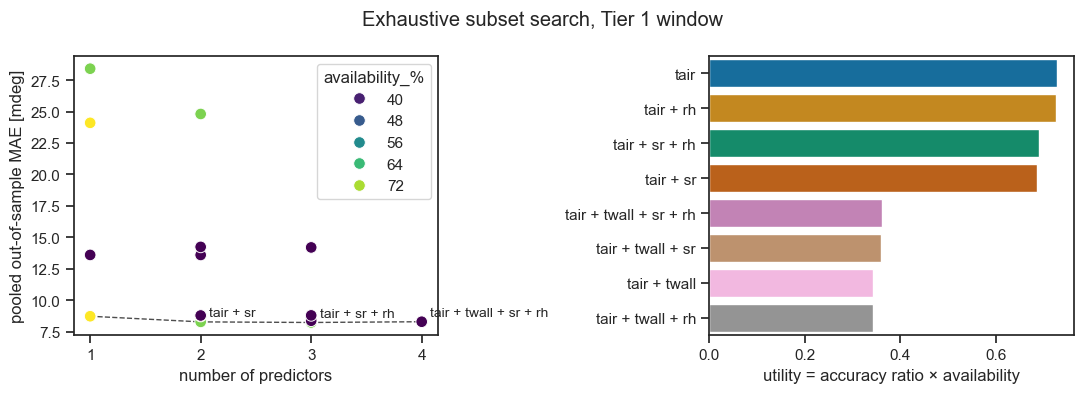

In [30]:
ip.plot_subset_search(
    subsets_t1, title='Exhaustive subset search, Tier 1 window',
    save_path=OUTPUT_DIR, filename=f'S3_F09_{STATION}_subsets_tier1')
plt.show()

In [31]:
subsets_t2 = ip.subset_search(
    tier2, TARGET, TIER2_DRIVERS, OPERATORS_T2, dt_hours=SAMPLING_HOURS,
    n_splits=CV_SPLITS, min_train_frac=MIN_TRAIN_FRAC, alpha=RIDGE_ALPHA,
    full_record=df)
display(subsets_t2)
subsets_t2.to_csv(f'{OUTPUT_DIR}/S3_14_{STATION}_subsets_tier2.csv')

,k,MAE_mdeg,RMSE_mdeg,R2,MAE_sd,BIC,availability_%,n_test,MAE_vs_best_%,utility
subset,,,,,,,,,,
tair + sr,2,5.9901,7.3301,0.7928,0.9274,24284.0,69.1,1718,0.00,0.6910
tair + sr + rh,3,6.1279,7.5155,0.7822,1.0000,24260.6,69.1,1718,2.30,0.6755
tair + rh,2,8.0168,9.2276,0.6717,3.0611,25080.1,77.1,1718,33.83,0.5761
tair,1,8.2464,9.4518,0.6555,3.0189,25205.2,77.1,1718,37.67,0.5600
rh,1,14.6657,17.2539,-0.1478,4.6400,29024.9,77.1,1718,144.83,0.3149
sr + rh,2,14.6959,17.3330,-0.1584,4.2722,28978.6,69.1,1718,145.34,0.2817
sr,1,18.5918,23.3949,-1.1103,8.1799,30817.7,69.1,1718,210.38,0.2226


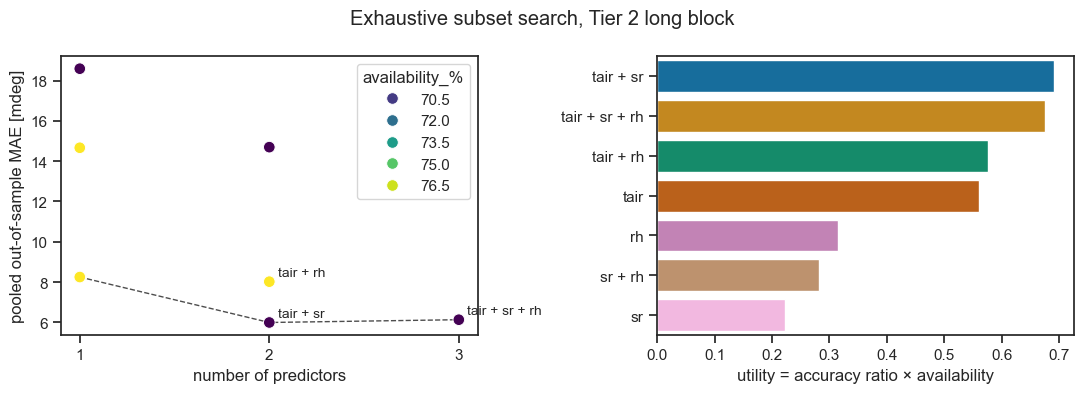

In [32]:
ip.plot_subset_search(
    subsets_t2, title='Exhaustive subset search, Tier 2 long block',
    save_path=OUTPUT_DIR, filename=f'S3_F10_{STATION}_subsets_tier2')
plt.show()

## Step 9 · Which member of the winning set is doing the work

Two diagnostics, deliberately different, because their disagreement is
informative.

**Leave-one-out gain** removes a channel and *refits*. It answers: what would
it cost to build this system without that channel? Under strong collinearity a
refit can recover much of the lost information from a correlated channel, so
this number is small exactly when the channel is replaceable.

**Permutation importance** shuffles a channel within the test block while
holding the fitted model fixed. It answers: how much does the model as built
rely on that channel? This number is large whenever the model leans on the
channel, replaceable or not.

A channel with high permutation importance and low leave-one-out gain is one
the model uses but does not need — the signature of a redundant sensor.

In [33]:
best_subset_t1 = subsets_t1.index[0].split(' + ')
print(f'Best Tier 1 subset by MAE: {" + ".join(best_subset_t1)}')

gain_t1 = ip.incremental_gain(
    tier1, TARGET, best_subset_t1, OPERATORS, dt_hours=SAMPLING_HOURS,
    n_splits=CV_SPLITS, min_train_frac=MIN_TRAIN_FRAC, alpha=RIDGE_ALPHA)
imp_t1 = ip.permutation_importance(
    tier1, TARGET, best_subset_t1, OPERATORS, dt_hours=SAMPLING_HOURS,
    n_splits=CV_SPLITS, min_train_frac=MIN_TRAIN_FRAC, alpha=RIDGE_ALPHA)
display(gain_t1)
display(imp_t1)
gain_t1.to_csv(f'{OUTPUT_DIR}/S3_15_{STATION}_gain_tier1.csv')
imp_t1.to_csv(f'{OUTPUT_DIR}/S3_16_{STATION}_importance_tier1.csv')

Best Tier 1 subset by MAE: tair + sr + rh


,MAE_full,MAE_without,gain_mdeg,gain_%
driver,,,,
tair,8.2399,24.8047,16.5648,66.78
sr,8.2399,8.7522,0.5123,5.85
rh,8.2399,8.2876,0.0477,0.58


,MAE_increase,sd
driver,,
tair,8.8396,2.4031
sr,0.0127,0.0186
rh,-0.0100,0.0256


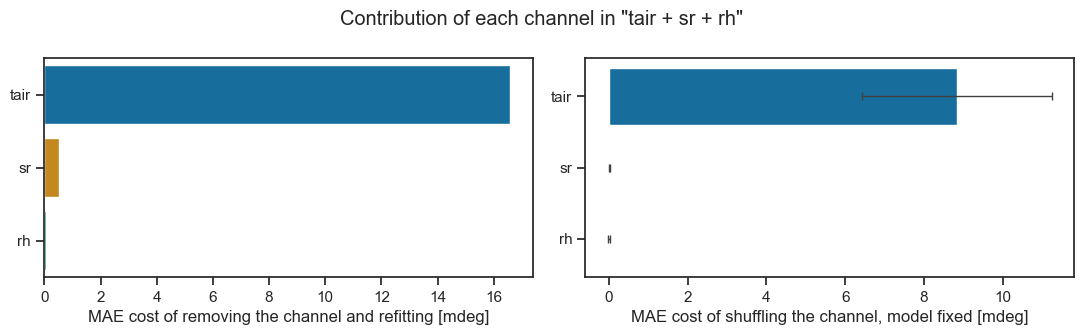

In [34]:
ip.plot_diagnostics(
    gain_t1, imp_t1,
    title=f'Contribution of each channel in "{" + ".join(best_subset_t1)}"',
    save_path=OUTPUT_DIR, filename=f'S3_F11_{STATION}_diagnostics')
plt.show()

### Out-of-period check

The Tier 1 model is refitted on the whole Tier 1 window and applied to the
detached summer block fourteen months later, without any refitting. This is the
hardest test in the study: a different season, a different part of the annual
cycle, and an instrument that has been through a 103-day outage in between.

In [35]:
holdout_rows = []
for label, cols in [('best subset', best_subset_t1),
                    ('best single', [rank_t1.index[0]])]:
    from sklearn.linear_model import Ridge
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import make_pipeline

    Xtr = ip.build_features(tier1, cols, OPERATORS, dt_hours=SAMPLING_HOURS)
    tr = Xtr.join(tier1[TARGET].rename('__y__')).dropna()
    Xte = ip.build_features(tier1_holdout, cols, OPERATORS,
                            dt_hours=SAMPLING_HOURS)
    te = Xte.join(tier1_holdout[TARGET].rename('__y__')).dropna()
    if len(tr) < 200 or len(te) < 100:
        continue
    model = make_pipeline(StandardScaler(), Ridge(alpha=RIDGE_ALPHA))
    model.fit(tr.drop(columns='__y__'), tr['__y__'])
    pred = model.predict(te.drop(columns='__y__'))
    err = pred - te['__y__'].values
    holdout_rows.append({
        'model': f'{label}: {" + ".join(cols)}',
        'n_test': len(te),
        'MAE_mdeg': round(float(np.abs(err).mean()), 4),
        'RMSE_mdeg': round(float(np.sqrt((err ** 2).mean())), 4),
    })
holdout = pd.DataFrame(holdout_rows).set_index('model')
display(holdout)
holdout.to_csv(f'{OUTPUT_DIR}/S3_17_{STATION}_holdout.csv')

,n_test,MAE_mdeg,RMSE_mdeg
model,,,
best subset: tair + sr + rh,1225,17.3863,20.0841
best single: tair,1225,16.9624,20.1165


## Step 10 · The diagnostic protocol

Question 2 asks not only which combination wins but how to tell. The procedure
used above is the answer, and it transfers to any station and any sensor set:

1. **Fit each driver's operator first, on the diurnal band.** Ranking raw
   channels penalises whichever driver happens to act through a lag.
2. **Score without autoregression.** With it, everything ties at short
   horizons and the ranking is uninformative.
3. **Use rolling-origin folds, never a single split.** The spread across folds
   is reported alongside the mean; differences smaller than that spread are
   ties, not orderings.
4. **Search subsets exhaustively when the candidate set is small.** Stepwise
   selection on collinear channels is unstable and biases the reported error.
5. **Never read coefficients under high VIF.** Use leave-one-out gain and
   permutation importance, and read their disagreement as redundancy.
6. **Price availability explicitly.** A channel absent for half the record
   cannot deliver during that half, whatever it scores where it is present.
7. **Carry a negative control.** A channel with no mechanism must rank last;
   if it does not, the procedure is measuring shape, not content.

In [36]:
protocol = pd.DataFrame({
    'step': range(1, 8),
    'rule': ['fit the operator before ranking',
             'score without autoregression',
             'rolling-origin folds, report the spread',
             'exhaustive subset search',
             'gain and permutation, never coefficients',
             'weight by availability over the whole record',
             'carry a negative control'],
    'failure it prevents': [
        'a lagged driver ranked below an instantaneous one',
        'every driver tying behind the autoregressive term',
        'a ranking that depends on where the single split fell',
        'selection bias and instability under collinearity',
        'importance attributed by collinearity rather than by content',
        'choosing a channel that is absent when it is needed',
        'mistaking shared diurnal shape for predictive content'],
}).set_index('step')
display(protocol)
protocol.to_csv(f'{OUTPUT_DIR}/S3_18_{STATION}_protocol.csv')

,rule,failure it prevents
step,,
1,fit the operator before ranking,a lagged driver ranked below an instantaneous one
2,score without autoregression,every driver tying behind the autoregressive term
3,"rolling-origin folds, report the spread",a ranking that depends on where the single spl...
4,exhaustive subset search,selection bias and instability under collinearity
5,"gain and permutation, never coefficients",importance attributed by collinearity rather t...
6,weight by availability over the whole record,choosing a channel that is absent when it is n...
7,carry a negative control,mistaking shared diurnal shape for predictive ...


## Step 11 · How far ahead, and with what uncertainty

**Question 3.** NeuralProphet is fitted with `n_forecasts` set to one week, so
a single training run yields every horizon from one hour to 168 and the whole
sweep comes from one fit rather than from eight.

Two regimes are run, and the difference between them is the point of the
exercise:

* **lagged** — the regressors enter only through their past values. This is
  what a deployed system has, and it is the honest number.
* **future** — the regressors are known across the forecast window. This is
  what the same system coupled to a perfect weather forecast would have, and it
  is a ceiling, not a result.

Reporting only one of them misstates the achievable skill in a predictable
direction. The gap between them prices what a weather forecast would be worth
to this installation.

Skill is measured against two baselines. **Persistence** carries the last
observation forward. **Seasonal naive** repeats the value from an integer
number of days earlier, which is the cheapest possible way to exploit the
diurnal cycle. The horizon at which skill against persistence reaches zero is
the answer to how far ahead this system can usefully forecast.

In [37]:
np_results, np_forecasts = {}, {}
if RUN_NEURALPROPHET:
    best_subset_t2 = subsets_t2.index[0].split(' + ')
    print(f'Tier 2 subset carried into the forecast study: '
          f'{" + ".join(best_subset_t2)}')

    jobs = [
        ('Tier 1, lagged', tier1, best_subset_t1, OPERATORS, 'lagged'),
        ('Tier 1, future', tier1, best_subset_t1, OPERATORS, 'future'),
        ('Tier 2, lagged', tier2, best_subset_t2, OPERATORS_T2, 'lagged'),
        ('Tier 2, future', tier2, best_subset_t2, OPERATORS_T2, 'future'),
    ]
    for label, window, subset, ops, regime in jobs:
        feats = ip.build_features(window, subset, ops,
                                  dt_hours=SAMPLING_HOURS)
        frame = feats.join(window[TARGET])
        res, fc = ip.run_horizon_experiment(
            frame, TARGET, subset, MAX_HORIZON, HORIZONS,
            freq=ANALYSIS_FREQ, regime=regime, n_lags=NP_LAGS,
            epochs=NP_EPOCHS, quantiles=QUANTILES,
            train_frac=NP_TRAIN_FRAC, keep_forecast=True)
        base = ip.baseline_errors(window[TARGET], HORIZONS, fc.index,
                                  dt_hours=SAMPLING_HOURS)
        np_results[label] = ip.add_skill(res, base)
        np_forecasts[label] = fc
        print(f'{label}: horizons scored {list(res.index)}')

Tier 2 subset carried into the forecast study: tair + sr


Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


Tier 1, lagged: horizons scored [1, 3, 6, 12, 24, 48, 72, 168]


Tier 1, future: horizons scored [1, 3, 6, 12, 24, 48, 72, 168]


Tier 2, lagged: horizons scored [1, 3, 6, 12, 24, 48, 72, 168]


Tier 2, future: horizons scored [1, 3, 6, 12, 24, 48, 72, 168]


In [38]:
if np_results:
    for label, res in np_results.items():
        print(f'\n=== {label} ===')
        display(res)
        tag = label.lower().replace(', ', '_').replace(' ', '')
        res.to_csv(f'{OUTPUT_DIR}/S3_19_{STATION}_horizons_{tag}.csv')


=== Tier 1, lagged ===


,MAE_mdeg,RMSE_mdeg,n,coverage_%,PI_width_mdeg,MAE_persistence,MAE_seasonal_naive,skill_vs_persistence,skill_vs_seasonal_naive
horizon_h,,,,,,,,,
1.0,4.4251,5.7368,1031,12.3,0.0000,3.4448,5.7580,-0.2846,0.2315
3.0,6.5408,8.5966,1031,11.9,0.0000,8.0334,5.7580,0.1858,-0.1359
6.0,10.4671,12.6916,1031,14.1,0.0000,14.5274,5.7580,0.2795,-0.8178
12.0,14.4211,16.8029,1031,9.8,0.0000,21.2000,5.7580,0.3198,-1.5045
24.0,21.6729,24.6472,1031,11.2,0.1513,5.7580,5.7580,-2.7640,-2.7640
48.0,35.9559,39.9144,1031,3.3,0.0000,7.8267,7.8267,-3.5940,-3.5940
72.0,48.4933,52.9486,1031,2.6,0.0000,8.3645,8.3645,-4.7975,-4.7975
168.0,52.8192,56.2290,1031,0.0,2.6807,10.6196,10.6196,-3.9737,-3.9737



=== Tier 1, future ===


,MAE_mdeg,RMSE_mdeg,n,coverage_%,PI_width_mdeg,MAE_persistence,MAE_seasonal_naive,skill_vs_persistence,skill_vs_seasonal_naive
horizon_h,,,,,,,,,
1.0,2.0330,2.6696,1030,18.0,0.0,3.4233,5.3294,0.4061,0.6185
3.0,2.2880,2.9742,1028,16.1,0.0,8.1818,5.3294,0.7204,0.5707
6.0,2.3742,3.0844,1025,17.6,0.0,14.8652,5.3294,0.8403,0.5545
12.0,2.4744,3.1266,1019,18.9,0.0,21.6100,5.3294,0.8855,0.5357
24.0,2.8542,3.6468,1007,23.4,0.0,5.3294,5.3294,0.4644,0.4644
48.0,3.4270,4.3394,983,20.9,0.0,7.3080,7.3080,0.5311,0.5311
72.0,4.1276,5.0128,959,22.7,0.0,8.0479,8.0479,0.4871,0.4871
168.0,7.3593,8.2825,863,21.3,0.0,10.9561,10.9561,0.3283,0.3283



=== Tier 2, lagged ===


,MAE_mdeg,RMSE_mdeg,n,coverage_%,PI_width_mdeg,MAE_persistence,MAE_seasonal_naive,skill_vs_persistence,skill_vs_seasonal_naive
horizon_h,,,,,,,,,
1.0,4.4281,5.8743,1031,61.4,15.2615,2.7939,6.1004,-0.5849,0.2741
3.0,5.5907,7.3891,1031,54.4,16.3261,6.8073,6.0938,0.1787,0.0826
6.0,6.3494,7.9249,1031,56.6,24.5789,11.7364,6.0856,0.4590,-0.0433
12.0,6.3455,7.8488,1031,53.6,18.4465,16.0556,6.0980,0.6048,-0.0406
24.0,6.9576,8.8604,1031,57.1,22.8663,6.0973,6.0973,-0.1411,-0.1411
48.0,8.0943,10.3221,1031,67.1,27.7202,8.3018,8.3018,0.0250,0.0250
72.0,9.6229,12.2119,1031,66.8,31.7212,9.6705,9.6705,0.0049,0.0049
168.0,15.9529,18.6662,1031,58.1,29.7374,12.2163,12.2163,-0.3059,-0.3059



=== Tier 2, future ===


,MAE_mdeg,RMSE_mdeg,n,coverage_%,PI_width_mdeg,MAE_persistence,MAE_seasonal_naive,skill_vs_persistence,skill_vs_seasonal_naive
horizon_h,,,,,,,,,
1.0,3.8218,5.1692,1030,95.4,39.9858,2.8597,6.1281,-0.3364,0.3763
3.0,5.1557,6.8549,1028,94.4,40.0752,6.9645,6.1204,0.2597,0.1576
6.0,5.8844,7.6277,1025,95.2,42.8055,12.0542,6.1110,0.5118,0.0371
12.0,6.0651,7.6670,1019,95.8,45.4756,16.6219,6.1253,0.6351,0.0098
24.0,6.4994,8.3721,1007,96.7,47.9198,6.1245,6.1245,-0.0612,-0.0612
48.0,7.9195,10.1527,983,95.4,50.3947,8.2081,8.2081,0.0352,0.0352
72.0,9.0598,11.4461,959,93.0,53.1116,9.4917,9.4917,0.0455,0.0455
168.0,13.0720,16.1097,863,82.7,50.6180,12.8379,12.8379,-0.0182,-0.0182


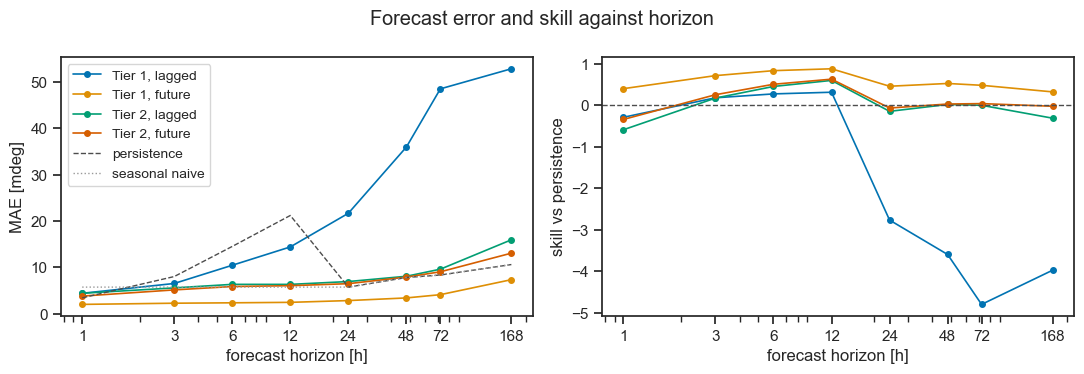

In [39]:
if np_results:
    ip.plot_horizon_skill(
        np_results,
        title='Forecast error and skill against horizon',
        save_path=OUTPUT_DIR, filename=f'S3_F12_{STATION}_horizon_skill')
    plt.show()

### Is the quoted uncertainty honest?

NeuralProphet is fitted with quantile regression at the 5th and 95th
percentiles, so every forecast carries a nominal ninety per cent prediction
interval. A nominal interval is only worth quoting if the observations actually
fall inside it at about that rate. The left panel below tests the calibration;
the right panel shows what the interval costs in width, because an interval can
always be made to cover by being made useless.

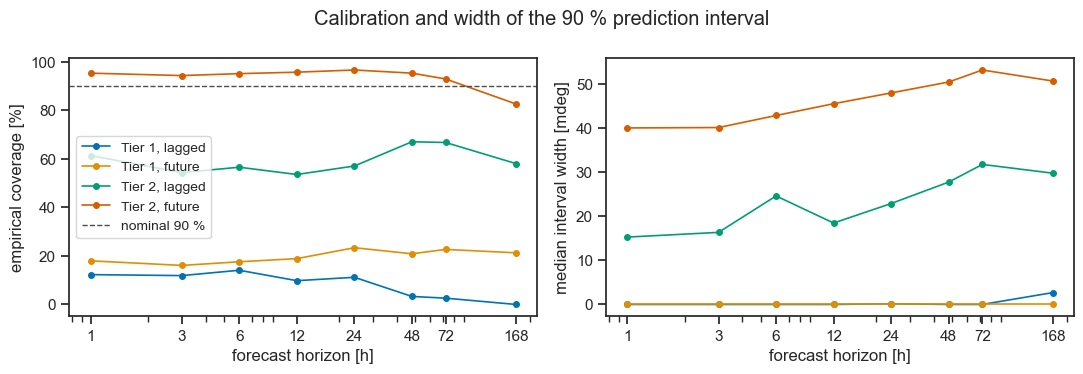

In [40]:
if np_results:
    ip.plot_uncertainty(
        np_results,
        title='Calibration and width of the 90 % prediction interval',
        save_path=OUTPUT_DIR, filename=f'S3_F13_{STATION}_uncertainty')
    plt.show()

In [41]:
if np_results:
    limits = pd.DataFrame([
        {'configuration': label,
         'last horizon beating persistence [h]':
             ip.horizon_limit(res, 'skill_vs_persistence'),
         'last horizon beating seasonal naive [h]':
             ip.horizon_limit(res, 'skill_vs_seasonal_naive'),
         'MAE at 24 h [mdeg]':
             res['MAE_mdeg'].get(24, np.nan),
         'coverage at 24 h [%]':
             res['coverage_%'].get(24, np.nan) if 'coverage_%' in res
             else np.nan}
        for label, res in np_results.items()
    ]).set_index('configuration')
    display(limits)
    limits.to_csv(f'{OUTPUT_DIR}/S3_20_{STATION}_horizon_limits.csv')

,last horizon beating persistence [h],last horizon beating seasonal naive [h],MAE at 24 h [mdeg],coverage at 24 h [%]
configuration,,,,
"Tier 1, lagged",12.0,1.0,21.6729,11.2
"Tier 1, future",168.0,168.0,2.8542,23.4
"Tier 2, lagged",72.0,72.0,6.9576,57.1
"Tier 2, future",72.0,72.0,6.4994,96.7


### One stretch of the forecast, drawn

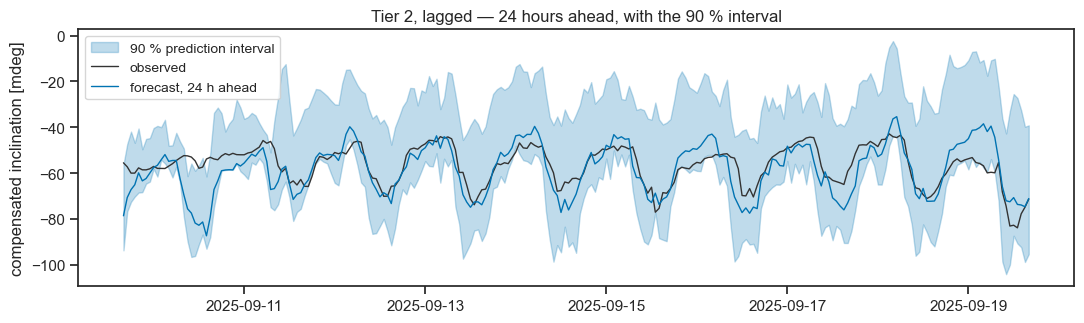

In [42]:
if np_forecasts:
    label = 'Tier 2, lagged' if 'Tier 2, lagged' in np_forecasts \
        else next(iter(np_forecasts))
    ip.plot_fan(
        np_forecasts[label], tier2[TARGET] if label.startswith('Tier 2')
        else tier1[TARGET],
        horizon=24, quantiles=QUANTILES, days=10,
        title=f'{label} — 24 hours ahead, with the 90 % interval',
        save_path=OUTPUT_DIR, filename=f'S3_F14_{STATION}_fan')
    plt.show()

### What the joint multi-horizon head costs

One fit produced every horizon, which is efficient but not free: the network
shares one set of weights across 168 output steps, and a model trained for a
single horizon can do better at that horizon. The check below refits at one
hour and at twenty-four hours with `n_forecasts` set to exactly that, and
compares. If the dedicated models win substantially, the horizon curve above
understates what the method can do and the report says so.

In [43]:
if RUN_NEURALPROPHET:
    dedicated_rows = []
    subset_ded = subsets_t2.index[0].split(' + ')
    feats = ip.build_features(tier2, subset_ded, OPERATORS_T2,
                              dt_hours=SAMPLING_HOURS)
    frame = feats.join(tier2[TARGET])
    for h in (1, 24):
        res = ip.run_horizon_experiment(
            frame, TARGET, subset_ded, h, [h], freq=ANALYSIS_FREQ,
            regime='lagged', n_lags=NP_LAGS, epochs=NP_EPOCHS,
            quantiles=QUANTILES, train_frac=NP_TRAIN_FRAC)
        joint = np_results.get('Tier 2, lagged')
        dedicated_rows.append({
            'horizon_h': h,
            'MAE_dedicated': res['MAE_mdeg'].iloc[0] if len(res) else np.nan,
            'MAE_joint_head': (joint['MAE_mdeg'].get(h, np.nan)
                               if joint is not None else np.nan),
        })
    dedicated = pd.DataFrame(dedicated_rows).set_index('horizon_h')
    dedicated['joint_head_penalty_%'] = (
        100 * (dedicated['MAE_joint_head'] - dedicated['MAE_dedicated'])
        / dedicated['MAE_dedicated']).round(2)
    display(dedicated)
    dedicated.to_csv(f'{OUTPUT_DIR}/S3_21_{STATION}_dedicated_vs_joint.csv')

,MAE_dedicated,MAE_joint_head,joint_head_penalty_%
horizon_h,,,
1,3.3009,4.4281,34.15
24,7.4468,6.9576,-6.57


## Step 12 · Verdicts

The three questions, answered from the tables above.

In [44]:
verdict_rows = [
    {'question': '1 · best single predictor',
     'answer': f'{rank_t1.index[0]} '
               f'(Tier 1, R² {rank_t1["R2"].iloc[0]:.3f}, '
               f'MAE {rank_t1["MAE_mdeg"].iloc[0]:.2f} mdeg); '
               f'{rank_t2.index[0]} on the long block '
               f'(R² {rank_t2["R2"].iloc[0]:.3f})'},
    {'question': '1 · negative control',
     'answer': f'{CONTROL} ranks '
               f'{list(rank_t1.index).index(CONTROL) + 1} of '
               f'{len(rank_t1)} in Tier 1'},
    {'question': '2 · best combination',
     'answer': f'{subsets_t1.index[0]} '
               f'(MAE {subsets_t1["MAE_mdeg"].iloc[0]:.2f} mdeg, '
               f'{subsets_t1["MAE_vs_best_%"].iloc[0]:.1f} % from best); '
               f'best by utility: {subsets_t1["utility"].idxmax()}'},
    {'question': '2 · gain over the best single',
     'answer': f'{100 * (rank_t1["MAE_mdeg"].iloc[0] - subsets_t1["MAE_mdeg"].iloc[0]) / rank_t1["MAE_mdeg"].iloc[0]:.1f} % '
               f'MAE reduction from the best single predictor'},
]
if np_results:
    for label, res in np_results.items():
        cov = (res['coverage_%'].get(24, float('nan'))
               if 'coverage_%' in res else float('nan'))
        verdict_rows.append({
            'question': f'3 · {label}',
            'answer': f'beats persistence out to '
                      f'{ip.horizon_limit(res, "skill_vs_persistence")} h; '
                      f'coverage at 24 h {cov:.0f} % against a nominal '
                      f'{res.attrs.get("nominal_coverage_%", 90):.0f} %'})
verdicts = pd.DataFrame(verdict_rows).set_index('question')
display(verdicts)
verdicts.to_csv(f'{OUTPUT_DIR}/S3_22_{STATION}_verdicts.csv')

,answer
question,
1 · best single predictor,"tair (Tier 1, R² 0.759, MAE 8.74 mdeg); tair o..."
1 · negative control,batt ranks 3 of 5 in Tier 1
2 · best combination,"tair + sr + rh (MAE 8.24 mdeg, 0.0 % from best..."
2 · gain over the best single,5.7 % MAE reduction from the best single predi...
"3 · Tier 1, lagged",beats persistence out to 12.0 h; coverage at 2...
"3 · Tier 1, future",beats persistence out to 168.0 h; coverage at ...
"3 · Tier 2, lagged",beats persistence out to 72.0 h; coverage at 2...
"3 · Tier 2, future",beats persistence out to 72.0 h; coverage at 2...


---

The full written evaluation, with every figure interpreted, is in
`report/inclination_prediction_report.pdf`.